# Add project to sys.path

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("LOKY_MAX_CPU_COUNT", os.environ.get("NUMBER_OF_PROCESSORS", "1"))

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "cnt_project").exists():
            return p
    raise RuntimeError("Could not locate project root containing src/cnt_project")

PROJECT_ROOT = _find_project_root(Path.cwd())

PROJECT_SRC_ROOT = PROJECT_ROOT / "src"
NOTEBOOK_ROOT = PROJECT_ROOT / "notebooks" / "paper_figures"
LEGACY_NOTEBOOK_ROOT = PROJECT_ROOT / "testing" / "Notebooks" / "Paper_figures"

for p in [str(PROJECT_SRC_ROOT), str(NOTEBOOK_ROOT), str(LEGACY_NOTEBOOK_ROOT)]:
    if p in sys.path:
        sys.path.remove(p)

# Main project package: cnt_project.*
sys.path.insert(0, str(PROJECT_SRC_ROOT))

# Current notebook helper package: src.*
sys.path.insert(0, str(NOTEBOOK_ROOT))

# Legacy helpers only as fallback
sys.path.insert(1, str(LEGACY_NOTEBOOK_ROOT))

# Imports

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science", "no-latex"])

from src.utils.paths import MODEL_OUTPUTS_ROOT as LEGACY_MODEL_OUTPUTS_ROOT, OUTPUTS
from src.utils.constants import (
    FIG_SIZES,
    SCORING_NAME_MAP,
    SCORING_COLOR_MAP,
    SCORING_EXPERIMENT_ORDER,
)
from cnt_project.visualizations.experiments.paper_figures.dice_plots import (
    plot_dice_boxstrip,
)
_output_root_candidates = [
    Path(LEGACY_MODEL_OUTPUTS_ROOT),
    PROJECT_ROOT / "global_outputs" / "reports" / "edt_comparison",
    PROJECT_ROOT / "Global_Outputs" / "reports" / "edt_comparison",
    PROJECT_ROOT / "global_outputs" / "runs",
]
MODEL_OUTPUTS_ROOT = next(
    (p for p in _output_root_candidates if p.exists()),
    Path(LEGACY_MODEL_OUTPUTS_ROOT),
)
print(f"Using MODEL_OUTPUTS_ROOT: {MODEL_OUTPUTS_ROOT}")

Using MODEL_OUTPUTS_ROOT: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\reports\edt_comparison


# Model lists, mappings, colors

In [4]:
stardist_list = [
    'fluo_new_edt',
    'fluo_edt_LB',
    'fluo_centerness',
    'fluo_edt_standard',
]

model_name_map = SCORING_NAME_MAP
color_map = SCORING_COLOR_MAP
experiment_order = SCORING_EXPERIMENT_ORDER

metric_file = "per_image_threshold_metrics_calc_dsb_map.csv"
iou_thresh_to_use = 0.5


# Load per-image DICE metrics

In [5]:
dice_dfs = []
summary = []

for exp_name in stardist_list:
    exp_path = MODEL_OUTPUTS_ROOT / exp_name
    file = exp_path / metric_file

    if not file.exists():
        print(f"[warn] Missing DICE file for: {exp_name}")
        continue

    df = pd.read_csv(file)

    # Validate required columns
    if "image_id" not in df.columns or "avg_dice" not in df.columns:
        print(f"[warn] Columns missing in: {exp_name}")
        continue

    # Exactly like your original code:
    df_unique = df.drop_duplicates(subset=["image_id"])[["image_id", "avg_dice"]].copy()
    df_unique["experiment"] = exp_name
    dice_dfs.append(df_unique)

# Merge results
all_dice_results = pd.concat(dice_dfs, ignore_index=True)

# Map to short labels (SYM, EDT, etc.)
all_dice_results['experiment'] = all_dice_results['experiment'].map(
    lambda x: model_name_map.get(x, x)
)

all_dice_results.head()


,image_id,avg_dice,experiment
0,1293-22_3_2_20230306222551,0.477829,EDT-SYM
1,400-1093-w11-c1p1-befo3-10sp-15flow_left,0.572796,EDT-SYM
2,400-1093-w11-c1p2-befo3-20sp-15flow_left,0.536584,EDT-SYM
3,400-1093-w13-c1-p1-10sp-15flow_left,0.597819,EDT-SYM
4,400-1093-w16-c-1-p1-10sp-15flow_left,0.573775,EDT-SYM


# Plot DICE Boxplot

## Note:
Please use inkscape to manually move the x labels EDT-SYM and EDT-FULL away from each other the fig size is too small and thefore they overlap 

c:\Users\abd93000\PycharmProjects\cnt_project_v2\src\cnt_project\visualizations\experiments\paper_figures\dice_plots.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
c:\Users\abd93000\PycharmProjects\cnt_project_v2\src\cnt_project\visualizations\experiments\paper_figures\dice_plots.py:43: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


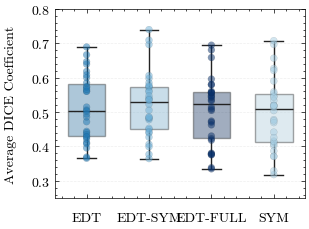

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\dice_boxplot_exact.svg


In [6]:
save_path = OUTPUTS['scoring'] / "dice_boxplot_exact.svg"

plot_dice_boxstrip(
    df=all_dice_results,
    color_map=color_map,
    order=experiment_order,
    figsize=FIG_SIZES["double_half"],
    ylim=(0.25, 0.8),
    save_path=save_path
)

print("Saved:", save_path)
